# Chapter 5 — Autoencoders and Latent Spaces

Every CNN you have built so far ends the same way: a stack of convolutions
crushes a 28×28 image down to a handful of numbers, and a classifier turns
those numbers into a label. The convolutions are the interesting part, since
they learn a *compressed description* of the image. The label is just what we
happened to ask for.

This chapter asks a different question of the same machinery: **can the
compressed description be turned back into the image?** If yes, then those few
numbers really do contain the picture, and the space they live in, the
**latent space**, is a map of everything the dataset contains. Learning to
walk around that map is the first form of generation.

| Module | What you build | Dataset (Hugging Face) |
|---|---|---|
| I | The reconstruction task, and a linear (PCA) baseline to beat | `zalando-datasets/fashion_mnist` |
| II | A convolutional **autoencoder**: encoder → 32-number bottleneck → decoder | `zalando-datasets/fashion_mnist` |
| III | Latent-space cartography: class map, interpolation, and the sampling **failure** | — |

The chapter ends on that failure rather than resolving it. That is deliberate:
the failure is precise, it is the central problem of generative modelling, and
the next three chapters are three different answers to it.

**How each concept is presented**, the same three passes as Chapters 1–3:

> 🧠 **The intuition:** the idea in plain language, no symbols.
> 📐 **The math:** the same idea written precisely, so you can read papers.
> 💻 **The code:** the same idea again, executable, in the cell that follows.

If a formula doesn't land, drop back to the intuition above it and read
forward again; they are three descriptions of one thing, not three topics.

**Runtime:** ~1 minute on a GPU, ~8 on CPU, for one training run. Every training
cell has a knob marked `# <- knob`. Fashion-MNIST downloads once (~30 MB) and is then
cached, exactly like MNIST and CIFAR-10 in Chapters 2 and 3.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from datasets import load_dataset
from sklearn.decomposition import PCA

keras.utils.set_random_seed(42)
rng = np.random.default_rng(seed=42)
plt.rcParams["figure.figsize"] = (7, 4.5)

print("TensorFlow", tf.__version__, "| Keras", keras.__version__)
print("GPU:", tf.config.list_physical_devices("GPU") or "none, so CPU only, which still works")

I0000 00:00:1787192274.715753   17783 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787192274.742795   17783 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1787192275.373501   17783 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


/home/mujtaba/venvs/datasci/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TensorFlow 2.21.0 | Keras 3.15.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


W0000 00:00:1787192276.365994   17783 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


---
# Module I — The Reconstruction Task

## I.a Load Fashion-MNIST from the Hub

Fashion-MNIST is MNIST's drop-in replacement: 70,000 28×28 grayscale images,
ten classes, same shape and size, but garments instead of digits. It is the
better choice here because clothing has *texture and structure* that a
reconstruction model can visibly succeed or fail at, while digits are so
simple that almost anything reconstructs them.

One thing to internalise before the code: from here on there are **no labels in
the training objective**. An autoencoder is **self-supervised**: the input is
the target. We keep the labels only to *color the plots* in Module III.


In [2]:
fashion = load_dataset("zalando-datasets/fashion_mnist")   # ~30 MB on first run, then cached
class_names = fashion["train"].features["label"].names
print(fashion)
print(class_names)


def split_to_arrays(split, n=None, image_col="image", label_col="label", seed=42):
    """Shuffle a HF split, optionally take the first n rows, return (images, labels)."""
    ds = split.shuffle(seed=seed)
    if n is not None:
        ds = ds.select(range(n))
    images = np.stack([np.array(im) for im in ds[image_col]])
    labels = np.array(ds[label_col])
    return images, labels


N_TRAIN = 20_000                                    # <- knob: up to 60_000
X_train_raw, y_train = split_to_arrays(fashion["train"], n=N_TRAIN)
X_test_raw,  y_test  = split_to_arrays(fashion["test"])

# Autoencoders want inputs in [0, 1] so a sigmoid output layer can match them exactly.
X_train = (X_train_raw / 255.0).astype("float32")[..., None]   # (N, 28, 28, 1)
X_test  = (X_test_raw  / 255.0).astype("float32")[..., None]

print("train:", X_train.shape, "| test:", X_test.shape, "| range:", X_train.min(), X_train.max())

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 60000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 10000
    })
})
['T - shirt / top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


train: (20000, 28, 28, 1) | test: (10000, 28, 28, 1) | range: 0.0 1.0


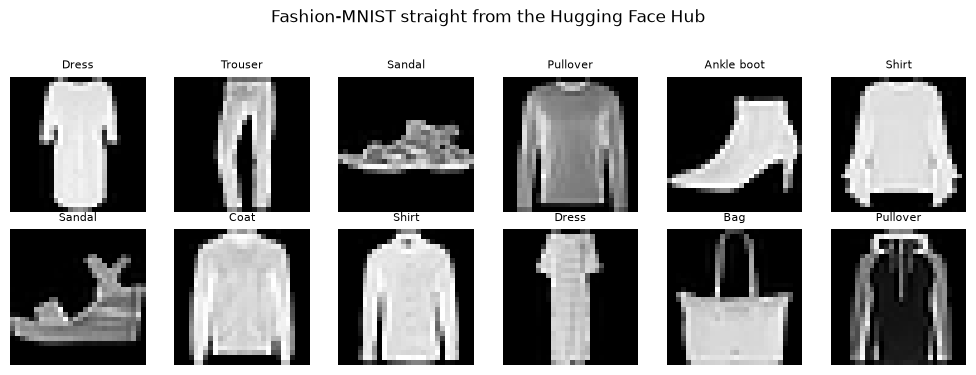

In [3]:
fig, axes = plt.subplots(2, 6, figsize=(10, 3.6))
for ax, img, label in zip(axes.flat, X_train_raw, y_train):
    ax.imshow(img, cmap="gray")
    ax.set_title(class_names[label], fontsize=8)
    ax.axis("off")
fig.suptitle("Fashion-MNIST straight from the Hugging Face Hub", y=1.03)
plt.tight_layout()
plt.show()

## I.b The baseline nobody tells you about: PCA

🧠 **The intuition.** Imagine you must describe a garment over the phone using
only 32 numbers, and the person on the other end has to draw it. You'd agree in
advance on 32 reference garments ("average t-shirt", "long-sleeve-ness",
"boot-ness") and then send how much of each to mix. That is PCA: it finds the
32 mixing ingredients that, blended together, get closest to every image in the
dataset. The catch is that *mixing* is all it can do. Every output is a weighted
average of the same 32 pictures.

📐 **The math.** A 28×28 image is a point $x \in \mathbb{R}^{784}$. PCA finds
the $k$-dimensional linear subspace capturing the most variance, giving you two
operations:

$$ \underbrace{z = W^\top (x - \mu)}_{\text{encode: } \mathbb{R}^{784} \to \mathbb{R}^{k}} \qquad\qquad \underbrace{\hat{x} = W z + \mu}_{\text{decode: } \mathbb{R}^{k} \to \mathbb{R}^{784}} $$

That is *exactly* an autoencoder (encoder, bottleneck, decoder) with the
restriction that both halves are single matrix multiplications. This is not an
analogy: a linear autoencoder trained with squared error provably converges to
the same subspace PCA finds.

So PCA is **the autoencoder you get when you forbid nonlinearity**. Whatever
our conv net achieves at the same bottleneck width $k = 32$, the gap over PCA
is precisely what depth and nonlinearity bought, which makes it the only
honest baseline for Module II.

💻 **The code.** `sklearn`'s `PCA` gives us `transform` (encode) and
`inverse_transform` (decode) directly.


In [4]:
LATENT_DIM = 32                                        # <- knob: try 2, 8, 32, 128

flat_train = X_train.reshape(len(X_train), -1)
flat_test  = X_test.reshape(len(X_test), -1)

pca = PCA(n_components=LATENT_DIM, random_state=42).fit(flat_train)
pca_codes = pca.transform(flat_test)                              # encode: 784 -> 32
pca_recon = pca.inverse_transform(pca_codes).reshape(X_test.shape)  # decode: 32 -> 784

pca_mse = np.mean((pca_recon - X_test) ** 2)
print(f"PCA with {LATENT_DIM} components")
print(f"  compression:   784 -> {LATENT_DIM} numbers  ({784 / LATENT_DIM:.0f}x)")
print(f"  variance kept: {pca.explained_variance_ratio_.sum():.1%}")
print(f"  test MSE:      {pca_mse:.5f}")

PCA with 32 components
  compression:   784 -> 32 numbers  (24x)
  variance kept: 82.7%
  test MSE:      0.01516


Here are 16 of the 32 "reference garments" PCA chose, and they make the
limitation concrete: grey, ghostly, whole-image templates. Every PCA
reconstruction in this notebook is a weighted mix of those 32 pictures and
nothing else.


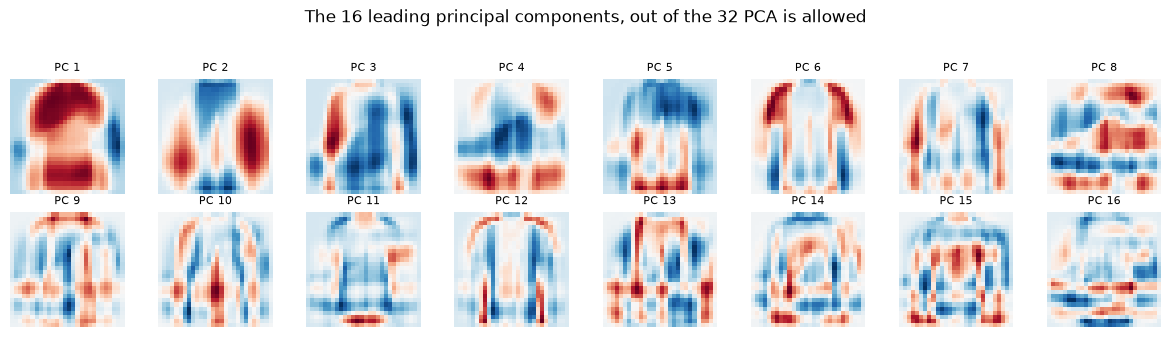

In [5]:
fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for i, ax in enumerate(axes.flat):
    ax.imshow(pca.components_[i].reshape(28, 28), cmap="RdBu_r")
    ax.set_title(f"PC {i + 1}", fontsize=8)
    ax.axis("off")
fig.suptitle("The 16 leading principal components, out of the 32 PCA is allowed", y=1.04)
plt.tight_layout()
plt.show()

---
# Module II — The Convolutional Autoencoder

🧠 **The intuition.** PCA had to describe an image as a blend of whole-image
templates. A convolutional encoder gets a far better vocabulary: instead of
"30% of template #4", it can say "there is an edge *here*, a texture *there*, a
curved sole in the lower left". It reuses the same small detectors everywhere
on the image, the weight-sharing property you already know from Chapter 2,
so its 32 numbers describe *arrangements of parts*, not proportions of averages.

## II.a The encoder: a CNN with its classifier head removed

🧠 **The intuition.** You have built this network before. It is your image
classifier with the last layer swapped: instead of ten neurons meaning "how
much does this look like each class", we use 32 neurons meaning "here are the
coordinates of this image". Nothing else changes. The convolutions still shrink
the picture step by step while growing the channel count, trading resolution
for meaning.

📐 **The math.** The encoder is a function $E_\phi : \mathbb{R}^{28 \times 28} \to \mathbb{R}^{32}$
with parameters $\phi$. Compare it to PCA's encoder $z = W^\top(x - \mu)$: same
signature, but $E_\phi$ is a composition of convolutions, poolings and ReLUs
rather than one matrix. The 32-dimensional output $z$ is called the **code**,
the **latent vector**, or the **bottleneck**.

💻 **The code.** The shape journey, layer by layer:

```
(28, 28, 1) → conv 32 → pool → (14, 14, 32) → conv 64 → pool → (7, 7, 64) → flatten → dense → (32,)
     784                            6272                        3136                       32
```

Note the numbers under the arrows: the image only truly becomes *compressed* at
the very last step. Everything before that is re-representation.


In [6]:
def build_encoder(latent_dim):
    inputs = keras.Input(shape=(28, 28, 1))
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs)   # 28x28x32
    x = layers.MaxPooling2D(2)(x)                                         # 14x14x32
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)        # 14x14x64
    x = layers.MaxPooling2D(2)(x)                                         #  7x7x64
    x = layers.Flatten()(x)                                               # 3136
    code = layers.Dense(latent_dim, name="code")(x)                       # 32  <- the bottleneck
    return keras.Model(inputs, code, name="encoder")


encoder = build_encoder(LATENT_DIM)
encoder.summary()

W0000 00:00:1787192279.957083   17783 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


I0000 00:00:1787192280.053076   17783 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 29127 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5090, pci bus id: 0000:01:00.0, compute capability: 12.0a


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ code (Dense)                    │ (None, 32)             │       100,384 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119,200 (465.62 KB)

 Trainable params: 119,200 (465.62 KB)

 Non-trainable params: 0 (0.00 B)

*(A note on `MaxPooling2D`: this is the classic textbook encoder, and we use it
here because it is the architecture you already know. Modern generative models,
including the GAN in Chapter 7 and the U-Net in Chapter 8, replace pooling
with **stride-2 convolutions**, which downsample by the same factor but *learn*
how to summarise each 2×2 neighbourhood instead of blindly taking the maximum.
You will see both, and can swap one for the other in a single line.)*

## II.b The decoder: convolution run backwards

🧠 **The intuition.** The decoder must undo every step the encoder took.
`Dense` and `Flatten` reverse easily. But how do you *un-pool*? Pooling took a
2×2 block and kept only the brightest pixel, so that information is gone
forever, and no operation recovers it.

So we don't try to recover it; we **learn to invent it**. Think of ordinary
convolution as *reading*: the kernel slides over the input and each stop
produces one summary number. A **transposed convolution** is *writing*: for
each input number, it stamps a whole kernel-shaped patch into the output,
stepping two output pixels at a time, adding up wherever stamps overlap. One
number in, a patch out. Same weights, same connectivity, arrows reversed.

📐 **The math.** An ordinary convolution is a linear map $y = Cx$ where $C$ is a
(very sparse, highly structured) matrix. The transposed convolution applies
$x = C^\top y$, literally the transpose, which is why it maps the small side
back to the large side. That is the whole content of the name; it is *not* a
deconvolution in the signal-processing sense and does not invert the original
convolution, it only reverses its **shape**.

⚠️ **One practical wart worth knowing now.** When the kernel size isn't
divisible by the stride, those overlapping stamps pile up unevenly, and some
output pixels receive more contributions than their neighbours, producing a
faint **checkerboard** texture. Kernel 3 with stride 2 is a mild offender;
kernel 4 with stride 2 divides cleanly, and `UpSampling2D` + ordinary `Conv2D`
sidesteps it entirely. We use kernel 3 and finish with a plain `Conv2D` that
smooths most of it away, but if you ever see suspicious grid texture in a
generated image, this is the first suspect.

💻 **The code.** The shape journey, in reverse:

```
(32,) → dense → (7, 7, 64) → convT ↑2 → (14, 14, 64) → convT ↑2 → (28, 28, 32) → conv → (28, 28, 1)
```


In [7]:
def build_decoder(latent_dim):
    codes = keras.Input(shape=(latent_dim,))
    x = layers.Dense(7 * 7 * 64, activation="relu")(codes)
    x = layers.Reshape((7, 7, 64))(x)                                                   #  7x7x64
    x = layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(x)  # 14x14x64
    x = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(x)  # 28x28x32
    out = layers.Conv2D(1, 3, padding="same", activation="sigmoid")(x)                  # 28x28x1
    return keras.Model(codes, out, name="decoder")


decoder = build_decoder(LATENT_DIM)
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3136)           │       103,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 159,169 (621.75 KB)

 Trainable params: 159,169 (621.75 KB)

 Non-trainable params: 0 (0.00 B)

Before training anything, here is transposed convolution stripped to its bones
(one 3×3 kernel, one 2×2 input, stride 2) so you can watch a stamp land.
Read the output: each input value scaled the kernel and pasted it two pixels
further along, and the overlap column in the middle is the sum of two stamps.


In [8]:
toy_in = np.array([[1.0, 2.0],
                   [3.0, 4.0]], dtype="float32").reshape(1, 2, 2, 1)
toy_kernel = np.array([[1.0, 1.0, 1.0],
                       [1.0, 1.0, 1.0],
                       [1.0, 1.0, 1.0]], dtype="float32").reshape(3, 3, 1, 1)

toy_layer = layers.Conv2DTranspose(1, 3, strides=2, padding="valid", use_bias=False)
toy_layer.build((None, 2, 2, 1))
toy_layer.set_weights([toy_kernel])
toy_out = toy_layer(toy_in).numpy().squeeze()

print("input (2x2):\n", toy_in.squeeze())
print("\nkernel (3x3): all ones")
print("\noutput (5x5), each input stamped the kernel, overlaps summed:\n", toy_out)

input (2x2):
 [[1. 2.]
 [3. 4.]]

kernel (3x3): all ones

output (5x5), each input stamped the kernel, overlaps summed:
 [[ 1.  1.  3.  2.  2.]
 [ 1.  1.  3.  2.  2.]
 [ 4.  4. 10.  6.  6.]
 [ 3.  3.  7.  4.  4.]
 [ 3.  3.  7.  4.  4.]]


I0000 00:00:1787192280.958730   17783 cuda_dnn.cc:461] Loaded cuDNN version 91900


## II.c Bolt them together and train

🧠 **The intuition.** Hand the model an image, let it squeeze the image down to
32 numbers and expand it back, then score it on how close the output is to what
went in. Nobody labelled anything: the image grades its own reconstruction.

📐 **The math.** With encoder $E_\phi$ and decoder $D_\theta$, minimise the
**reconstruction error** over the dataset:

$$ \min_{\phi,\, \theta}\; \frac{1}{N}\sum_{i=1}^{N} \big\| x_i - D_\theta(E_\phi(x_i)) \big\|_2^2 $$

Note what forces learning: if the bottleneck were 784-wide the model could just
copy. At 32 it *must* discard 96% of the numbers, so it has to discard the
**predictable** ones and keep the informative ones. The bottleneck is the
entire teacher.

💻 **The code.** All of that is one line, and it's the line that makes
autoencoders click:

```python
autoencoder.fit(X_train, X_train)     # the input IS the label
```

No annotation, no human in the loop, and the supervision comes free with the
data. That is what "self-supervised" means, and it is the same principle that
lets language models learn from raw text by predicting the next token.


In [9]:
inputs = keras.Input(shape=(28, 28, 1))
autoencoder = keras.Model(inputs, decoder(encoder(inputs)), name="conv_autoencoder")
autoencoder.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")

EPOCHS = 20                                            # <- knob
history = autoencoder.fit(X_train, X_train,            # <- input IS the target
                          validation_data=(X_test, X_test),
                          epochs=EPOCHS, batch_size=128, verbose=2)

ae_mse = autoencoder.evaluate(X_test, X_test, verbose=0)
print(f"\nconv autoencoder test MSE: {ae_mse:.5f}")
print(f"PCA test MSE:              {pca_mse:.5f}   ({pca_mse / ae_mse:.2f}x worse)")

Epoch 1/20


I0000 00:00:1787192281.856622   17941 service.cc:153] XLA service 0x731c30049370 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1787192281.856660   17941 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5090, Compute Capability 12.0a (Driver: 13.3.0; Runtime: 12.8.0; Toolkit: 12.5.0; DNN: 9.19.0)
I0000 00:00:1787192281.877933   17941 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1787192282.022848   17941 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2557__.26


I0000 00:00:1787192282.568883   18047 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_4', 20 bytes spill stores, 20 bytes spill loads



I0000 00:00:1787192284.990846   17941 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


I0000 00:00:1787192285.490573   17942 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2557__.26


...

Epoch 19/20


157/157 - 1s - 4ms/step - loss: 0.0078 - val_loss: 0.0083


Epoch 20/20


157/157 - 1s - 4ms/step - loss: 0.0077 - val_loss: 0.0083



conv autoencoder test MSE: 0.00826
PCA test MSE:              0.01516   (1.84x worse)


## II.d Look at the reconstructions

Numbers are not the point. What matters is what survives the 24× squeeze and
what doesn't. Middle row is PCA, bottom row is the conv autoencoder, both
working from exactly 32 numbers per image.


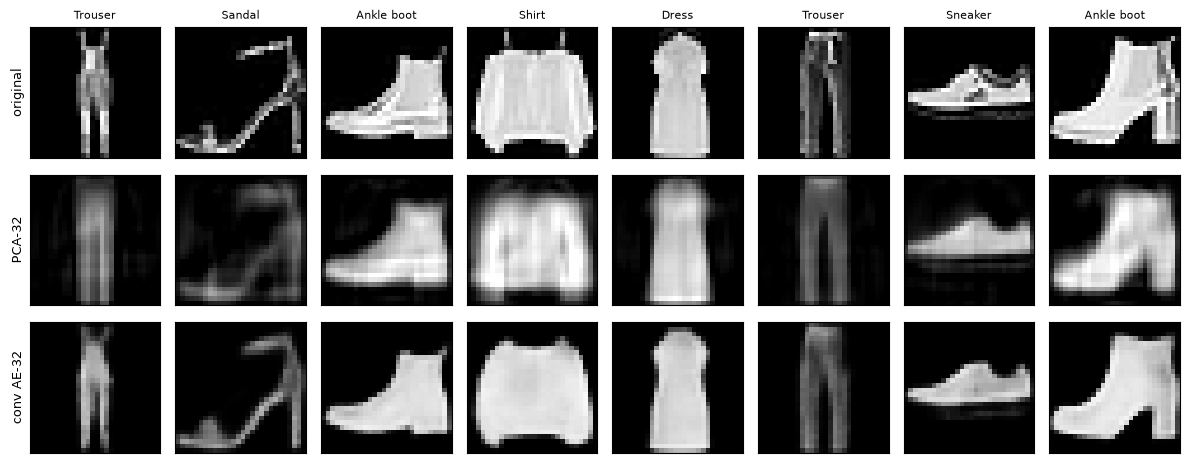

In [10]:
ae_recon = autoencoder.predict(X_test, verbose=0)

pick = rng.choice(len(X_test), size=8, replace=False)
fig, axes = plt.subplots(3, 8, figsize=(12, 4.8))
for col, idx in enumerate(pick):
    for row, img in enumerate([X_test[idx], pca_recon[idx], ae_recon[idx]]):
        axes[row, col].imshow(img.squeeze(), cmap="gray", vmin=0, vmax=1)
        axes[row, col].set_xticks([]); axes[row, col].set_yticks([])
    axes[0, col].set_title(class_names[y_test[idx]], fontsize=8)

for row, tag in enumerate(["original", f"PCA-{LATENT_DIM}", f"conv AE-{LATENT_DIM}"]):
    axes[row, 0].set_ylabel(tag, fontsize=9)
plt.tight_layout()
plt.show()

**What to look for:** PCA reconstructions are *ghosted*, since every image is a
blend of average garments, so sleeves smear and prints dissolve into grey haze.
The conv autoencoder keeps silhouettes crisp and preserves local detail like the
gap between trouser legs or the strap of a sandal, because it can encode "there
is an edge here" rather than "this image is 0.3 shirts plus 0.2 boots".

Both are still **blurry** relative to the original, and that is MSE's
fingerprint. Here is why, and it matters for the rest of the curriculum: when
the model is unsure whether a texture detail is present, squared error rewards
*hedging*. Outputting the average of "detail" and "no detail" has a lower
expected squared error than committing to either, and the average of two
sharp possibilities is a smudge.

**Remember this paragraph.** Every model in this chapter trained with pixel MSE
is soft for this reason; Chapters 7 and 8 are two different escapes from it,
and Chapter 8's escape is to keep MSE and change what it is applied to.


---
# Module III — Cartography of the Latent Space

We now have a map from images to 32 numbers and back. What does that space
look like? Three experiments, and the third one fails, informatively.

## III.a Does the latent space organise itself by class?

🧠 **The intuition.** The encoder was never told what a sneaker is. But to
reconstruct sneakers efficiently it needs a compact way to say "sneaker-ish
thing", and the cheapest way to do that is to park all sneakers in the same
neighbourhood. If we now color the codes by the labels we withheld, any
clustering we see is organisation the model *discovered*, not organisation we
imposed.

📐 **The math.** PCA centers the codes and finds the two orthonormal
directions of greatest variance, the top eigenvectors $v_1, v_2$ of the
covariance matrix

$$\Sigma = \frac{1}{N} \sum_i (z_i - \bar{z})(z_i - \bar{z})^\top,$$

and maps each code to $\left((z - \bar{z})^\top v_1,\; (z - \bar{z})^\top v_2\right)$,
the 2-D shadow that preserves more of the cloud's spread than any other
linear projection.

💻 **The code.** 32 dimensions won't fit on a screen, so we project down to 2
with PCA, a fast, honest linear view of where the cloud is widest.


latent codes: (10000, 32) | mean per-dim std: 3.778


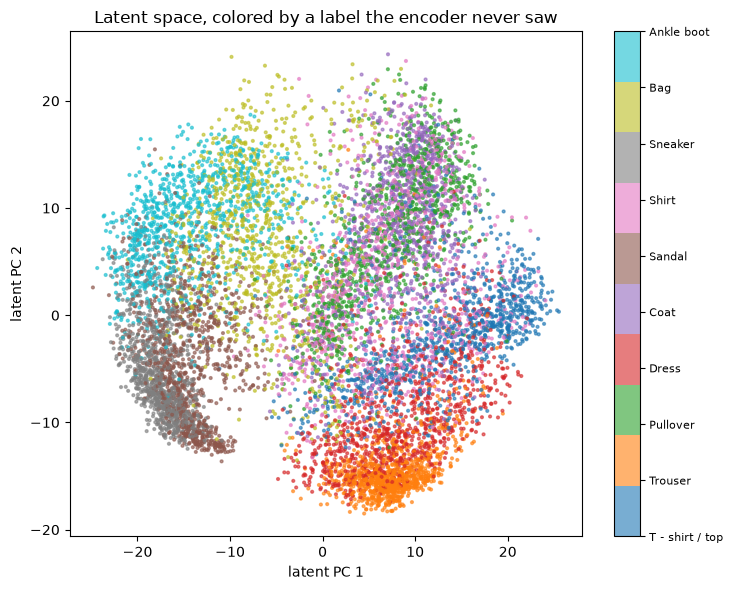

In [11]:
codes_test = encoder.predict(X_test, verbose=0)
print("latent codes:", codes_test.shape, "| mean per-dim std:", codes_test.std(axis=0).mean().round(3))

codes_2d = PCA(n_components=2, random_state=42).fit_transform(codes_test)

plt.figure(figsize=(7.5, 6))
scatter = plt.scatter(codes_2d[:, 0], codes_2d[:, 1], c=y_test, cmap="tab10", s=4, alpha=0.6)
cbar = plt.colorbar(scatter, ticks=range(10))
cbar.ax.set_yticklabels(class_names, fontsize=8)
plt.title("Latent space, colored by a label the encoder never saw")
plt.xlabel("latent PC 1"); plt.ylabel("latent PC 2")
plt.tight_layout()
plt.show()

Footwear clusters away from tops; trousers and bags carve out their own
territory; shirt / coat / pullover overlap heavily, which is exactly the
confusion a *supervised* Fashion-MNIST classifier makes too. The geometry of
the latent space encodes semantics, learned from reconstruction pressure alone.

## III.b Interpolation: walking between two garments

🧠 **The intuition.** If this space is a real map, then travelling in a straight
line from "sneaker" to "bag" should pass through things that are *part sneaker,
part bag*, not through nonsense. That is a strong claim about the space, and
it is easy to test: take two codes, mix them in steps, decode each mixture.

📐 **The math.** Linear interpolation between two codes, decoded:

$$ z_\alpha = (1 - \alpha)\, z_A + \alpha\, z_B, \qquad \alpha \in [0, 1], \qquad \text{show } D_\theta(z_\alpha) $$

Note that mixing in *pixel* space would just cross-fade two photos, a double
exposure. Mixing in *latent* space is a different operation entirely, and the
difference between the two is the payoff of the whole notebook.

💻 **The code.**


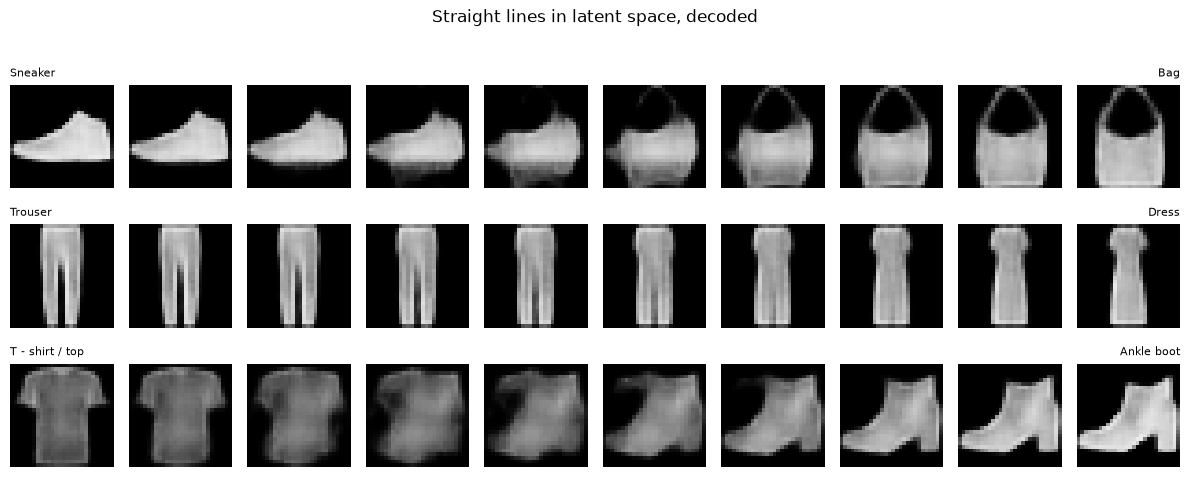

In [12]:
def interpolate(idx_a, idx_b, steps=10):
    alpha = np.linspace(0, 1, steps)[:, None]
    z_mix = (1 - alpha) * codes_test[idx_a] + alpha * codes_test[idx_b]
    return decoder.predict(z_mix.astype("float32"), verbose=0)


pairs = [(int(np.flatnonzero(y_test == a)[0]), int(np.flatnonzero(y_test == b)[0]))
         for a, b in [(7, 8), (1, 3), (0, 9)]]      # sneaker→bag, trouser→dress, t-shirt→boot

fig, axes = plt.subplots(len(pairs), 10, figsize=(12, 1.6 * len(pairs)))
for row, (ia, ib) in enumerate(pairs):
    for ax, img in zip(axes[row], interpolate(ia, ib)):
        ax.imshow(img.squeeze(), cmap="gray", vmin=0, vmax=1)
        ax.axis("off")
    axes[row, 0].set_title(class_names[y_test[ia]], fontsize=8, loc="left")
    axes[row, -1].set_title(class_names[y_test[ib]], fontsize=8, loc="right")
fig.suptitle("Straight lines in latent space, decoded", y=1.02)
plt.tight_layout()
plt.show()

The middle frames are the interesting ones. Sometimes you get a genuine
hybrid, such as a bag growing a sole. Sometimes you get a **cross-fade**: two
ghosts superimposed, which is the tell-tale sign that the line passed through a
region the encoder never populated, and the decoder had no idea what belongs
there. Hold on to that observation; it is about to become the whole point.

## III.c The experiment that fails: sampling

🧠 **The intuition.** Here is the obvious way to *generate* a new garment. We
have a decoder that turns 32 numbers into a picture. The real codes hover
around zero with a certain spread. So: roll 32 random numbers with that same
spread, decode, and collect your novel design. Nothing about that reasoning
sounds wrong. It is about to produce grey fog.

💻 **The code.**


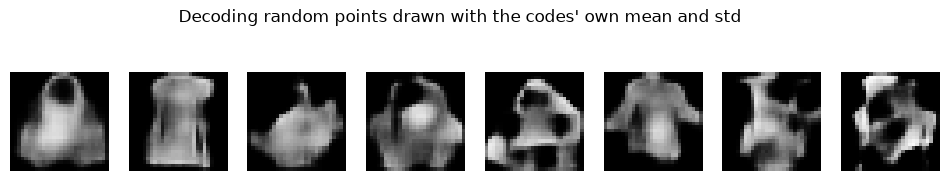

In [13]:
z_random = rng.normal(loc=codes_test.mean(axis=0),
                      scale=codes_test.std(axis=0),
                      size=(8, LATENT_DIM)).astype("float32")
fake = decoder.predict(z_random, verbose=0)

fig, axes = plt.subplots(1, 8, figsize=(12, 1.8))
for ax, img in zip(axes, fake):
    ax.imshow(img.squeeze(), cmap="gray", vmin=0, vmax=1)
    ax.axis("off")
fig.suptitle("Decoding random points drawn with the codes' own mean and std", y=1.12)
plt.show()

**Smudges.** Not garments, not even *bad* garments, but structureless grey fog.

🧠 **Why, in plain terms.** Nothing in the training objective ever asked the
latent space to be *filled in*. The autoencoder's job was to reconstruct 20,000
specific images, so it only ever had to make 20,000 specific points decode
well. Between and around them, the decoder is unconstrained, and it used that
freedom. The codes form a sparse, lumpy, hole-riddled cloud, and matching its
mean and spread *per axis* tells you almost nothing about where the cloud
actually is.

📐 **Why, precisely.** We sampled from the product of the per-axis marginals,
$\prod_j \mathcal{N}(\mu_j, \sigma_j^2)$, but the codes live on the true
aggregate posterior $q(z) = \frac{1}{N}\sum_i \delta(z - E_\phi(x_i))$. These
agree on every axis separately and can still be almost disjoint as sets. High
dimension makes it worse: a Gaussian in $d$ dimensions concentrates its mass in
a thin shell at radius $\sigma\sqrt{d}$, so at $d = 32$ virtually every draw
lands far from the origin *and* far from any real code, in a void the decoder
has never been trained on.

This is the central problem of generative modelling, stated precisely:

> It is not enough to map data into a latent space. You need a latent space you
> know how to **sample from**, one where the distribution you draw from and
> the distribution the decoder was trained on are the *same distribution*.

There are three famous answers, and they are the rest of the generative
sequence:

1. **Force the latent space into a shape you can sample**: the VAE, Chapter 6.
2. **Skip the encoder; train a sampler adversarially**: the GAN, Chapter 7.
3. **Use a latent space that is noise by construction**: diffusion, Chapter 8.


---
# Wrap-Up

| You built | The transferable lesson |
|---|---|
| PCA as a linear autoencoder | An autoencoder is PCA with the linearity restriction lifted; the gap is what depth buys |
| Conv encoder + `Conv2DTranspose` decoder | The CNN you know, run backwards; transposed convolution is a *learned* upsampler (watch for checkerboards) |
| The latent class map | Structure emerges with no labels at all, since reconstruction pressure alone sorts sneakers from shirts |
| Interpolation | Mixing in latent space is a different operation from cross-fading in pixel space, and the middle frames tell you which one you got |
| The sampling failure | A latent space you can't sample from is not a generative model |

**Two lessons to carry forward, and both come back repeatedly.**

**The blur is MSE's fingerprint.** Every model here optimizes a per-pixel
distance, and per-pixel distances reward hedging. That single fact drives the
next three chapters.

**The hole-riddled latent space is the central problem of generative
modelling.** Chapter 6 fixes it by reshaping the latent space into something
samplable; Chapter 7 skips the encoder entirely and trains a sampler
adversarially; Chapter 8 uses a latent space that is noise by construction.
Three answers, three chapters, all of them reactions to the grey fog above.
